In [1]:
# Install KaggleHub if needed
!pip install -q kagglehub

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [3]:
# Find all JPG images inside the downloaded dataset
image_paths = glob(os.path.join(path, "**", "*.jpg"), recursive=True)

print("Total images found:", len(image_paths))

# Display first 10 image paths
for img_path in image_paths[:10]:
    print(img_path)

Total images found: 20030
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0026412.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024872.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0026232.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027031.jpg


In [4]:
# Select 5 images from the dataset
selected_images = image_paths[:5]

print("Selected Images:")
for i, img_path in enumerate(selected_images, start=1):
    print(f"Image {i}: {img_path}")

Selected Images:
Image 1: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
Image 2: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
Image 3: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
Image 4: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
Image 5: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg


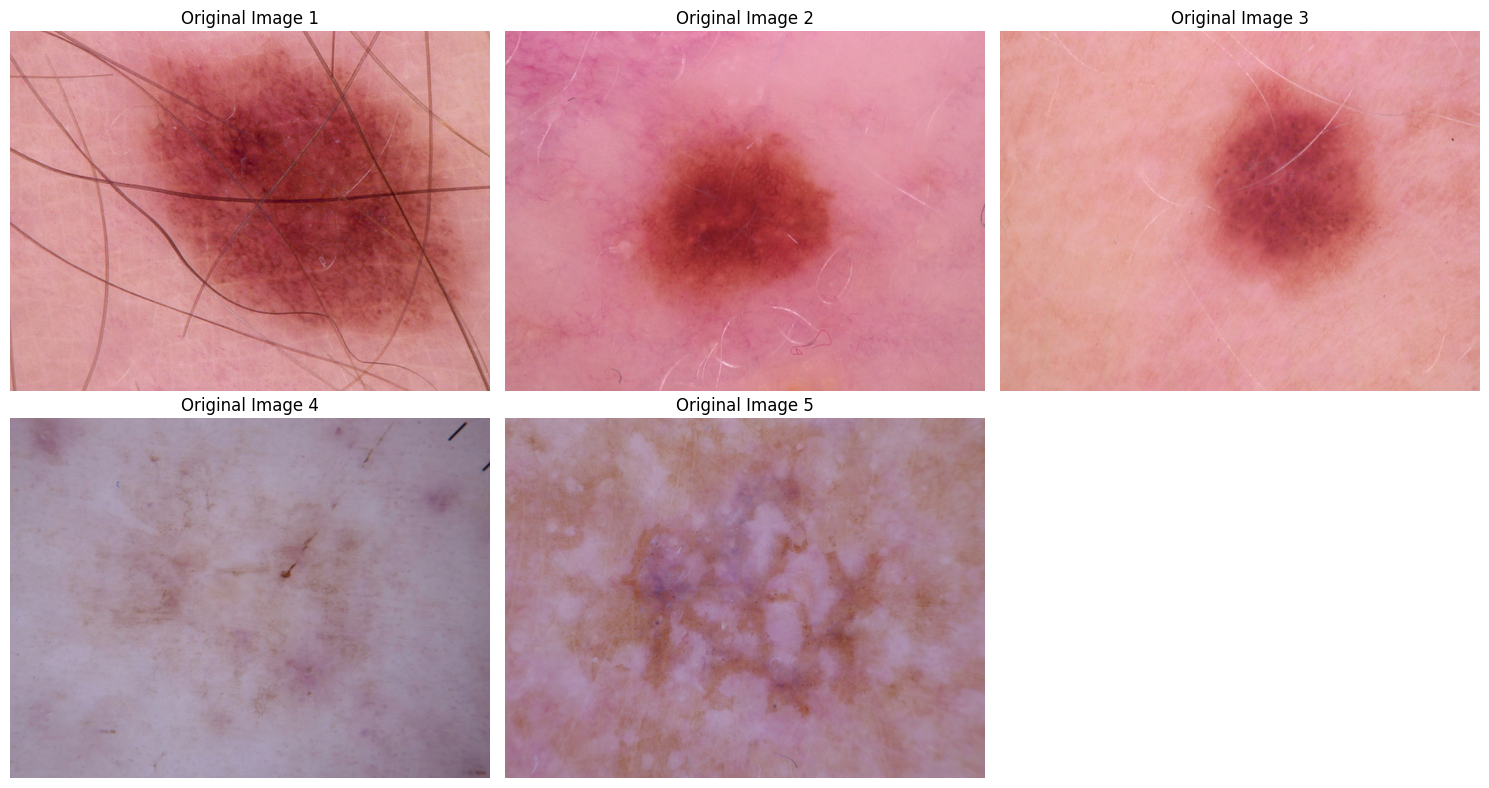

In [5]:
plt.figure(figsize=(15, 8))

for i, img_path in enumerate(selected_images):
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(f"Original Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

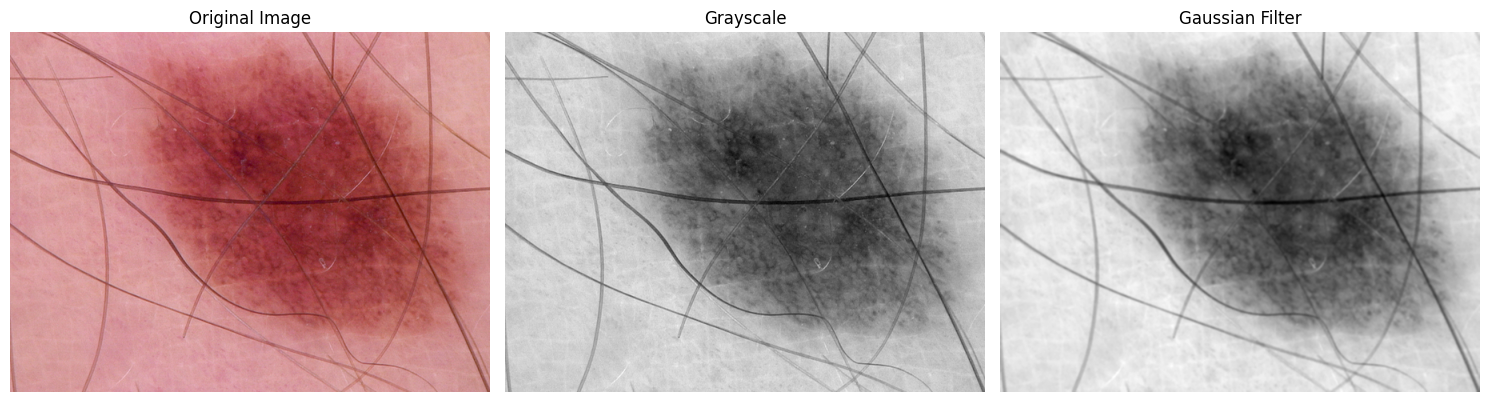

In [6]:
# Load the first selected image
image = cv2.imread(selected_images[0])

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur
gaussian = cv2.GaussianBlur(gray, (5, 5), 0)

# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

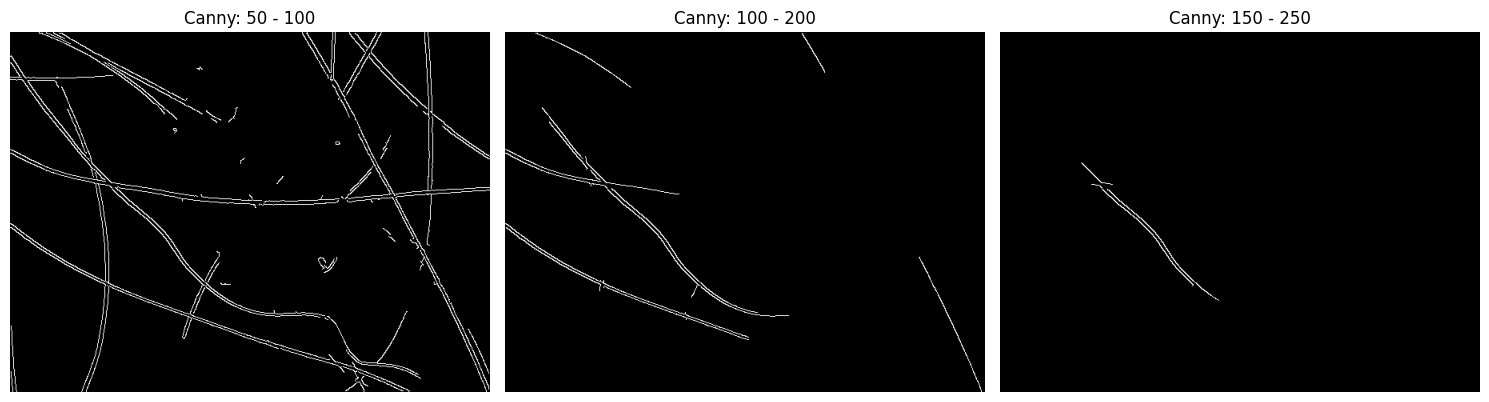

In [7]:
# Apply Canny Edge Detection with three threshold settings

edges_50_100 = cv2.Canny(gaussian, 50, 100)

edges_100_200 = cv2.Canny(gaussian, 100, 200)

edges_150_250 = cv2.Canny(gaussian, 150, 250)

# Display all three edge maps
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(edges_50_100, cmap="gray")
plt.title("Canny: 50 - 100")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edges_100_200, cmap="gray")
plt.title("Canny: 100 - 200")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edges_150_250, cmap="gray")
plt.title("Canny: 150 - 250")
plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Count edge pixels for each threshold

edge_count_50_100 = np.sum(edges_50_100 > 0)
edge_count_100_200 = np.sum(edges_100_200 > 0)
edge_count_150_250 = np.sum(edges_150_250 > 0)

print("Edge pixels:")
print("50-100   :", edge_count_50_100)
print("100-200  :", edge_count_100_200)
print("150-250  :", edge_count_150_250)

Edge pixels:
50-100   : 9479
100-200  : 2677
150-250  : 585


In [9]:
best_edges = edges_100_200
best_threshold = "100-200"

print("Selected Threshold:", best_threshold)

Selected Threshold: 100-200


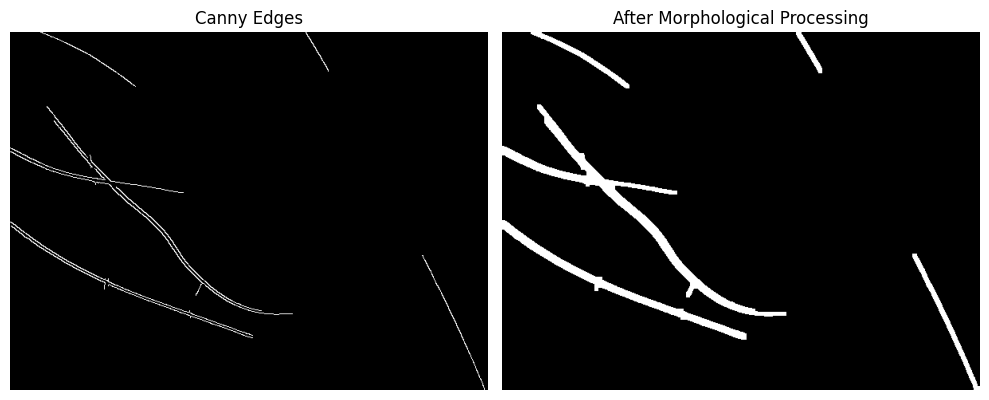

In [10]:
# Create a morphological kernel
kernel = np.ones((5, 5), np.uint8)

# Close small gaps in the edges
closed_edges = cv2.morphologyEx(
    best_edges,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

# Dilate slightly to strengthen the boundary
closed_edges = cv2.dilate(
    closed_edges,
    kernel,
    iterations=1
)

# Display result
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(best_edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(closed_edges, cmap="gray")
plt.title("After Morphological Processing")
plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# Find contours
contours, hierarchy = cv2.findContours(
    closed_edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours detected:", len(contours))

Number of contours detected: 5


In [12]:
if len(contours) > 0:

    # Select largest contour
    largest_contour = max(contours, key=cv2.contourArea)

    # Calculate area
    lesion_area = cv2.contourArea(largest_contour)

    # Calculate perimeter
    lesion_perimeter = cv2.arcLength(
        largest_contour,
        True
    )

    print("Lesion Area:", lesion_area, "pixels")
    print("Lesion Perimeter:", lesion_perimeter, "pixels")

else:
    print("No contour detected.")

Lesion Area: 5563.5 pixels
Lesion Perimeter: 1342.9473898410797 pixels


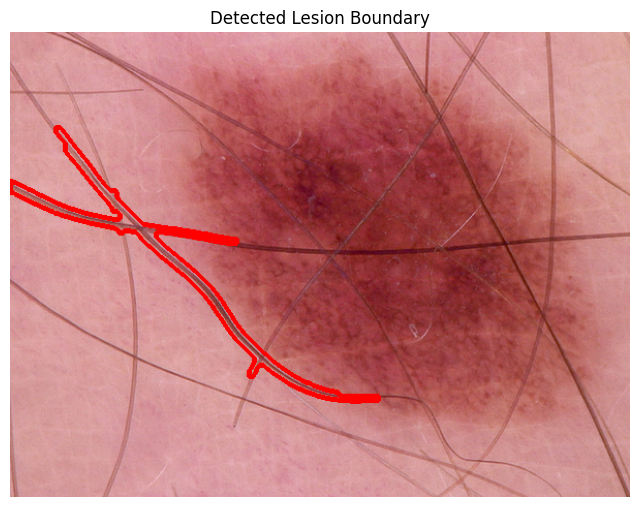

In [13]:
# Copy original image
boundary_image = image_rgb.copy()

# Draw largest contour
cv2.drawContours(
    boundary_image,
    [largest_contour],
    -1,
    (255, 0, 0),
    3
)

# Display
plt.figure(figsize=(8, 8))

plt.imshow(boundary_image)
plt.title("Detected Lesion Boundary")
plt.axis("off")

plt.show()

In [14]:
print("=" * 50)
print("LESION DETECTION RESULTS")
print("=" * 50)

print(f"Best Canny Threshold : {best_threshold}")
print(f"Lesion Area          : {lesion_area:.2f} pixels")
print(f"Lesion Perimeter     : {lesion_perimeter:.2f} pixels")

LESION DETECTION RESULTS
Best Canny Threshold : 100-200
Lesion Area          : 5563.50 pixels
Lesion Perimeter     : 1342.95 pixels


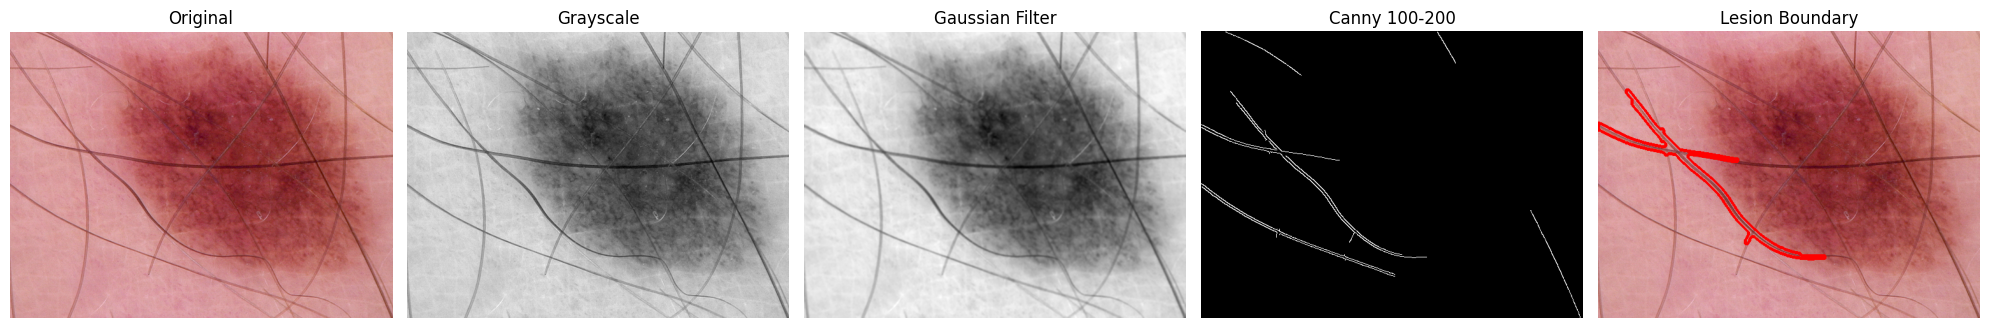

In [15]:
plt.figure(figsize=(20, 5))

# Original
plt.subplot(1, 5, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

# Grayscale
plt.subplot(1, 5, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

# Gaussian
plt.subplot(1, 5, 3)
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")

# Canny
plt.subplot(1, 5, 4)
plt.imshow(best_edges, cmap="gray")
plt.title(f"Canny {best_threshold}")
plt.axis("off")

# Boundary
plt.subplot(1, 5, 5)
plt.imshow(boundary_image)
plt.title("Lesion Boundary")
plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
results = []

for i, img_path in enumerate(selected_images, start=1):

    # Read image
    img = cv2.imread(img_path)

    # Convert to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Grayscale
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Gaussian filtering
    gaussian_img = cv2.GaussianBlur(
        gray_img,
        (5, 5),
        0
    )

    # Canny
    edges = cv2.Canny(
        gaussian_img,
        100,
        200
    )

    # Morphological closing
    kernel = np.ones((5, 5), np.uint8)

    processed_edges = cv2.morphologyEx(
        edges,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    # Dilate
    processed_edges = cv2.dilate(
        processed_edges,
        kernel,
        iterations=1
    )

    # Find contours
    contours, _ = cv2.findContours(
        processed_edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) > 0:

        # Largest contour
        largest = max(
            contours,
            key=cv2.contourArea
        )

        # Area
        area = cv2.contourArea(largest)

        # Perimeter
        perimeter = cv2.arcLength(
            largest,
            True
        )

    else:
        area = 0
        perimeter = 0

    # Store results
    results.append({
        "Image": f"Image {i}",
        "Best Filter": "Gaussian",
        "Edge Method": "Canny (100-200)",
        "Area (pixels)": round(area, 2),
        "Perimeter (pixels)": round(perimeter, 2)
    })


# Create DataFrame
results_df = pd.DataFrame(results)

# Display table
results_df

,Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,Image 1,Gaussian,Canny (100-200),5563.5,1342.95
1,Image 2,Gaussian,Canny (100-200),0.0,0.00
2,Image 3,Gaussian,Canny (100-200),814.5,212.63
3,Image 4,Gaussian,Canny (100-200),318.5,83.15
4,Image 5,Gaussian,Canny (100-200),0.0,0.00


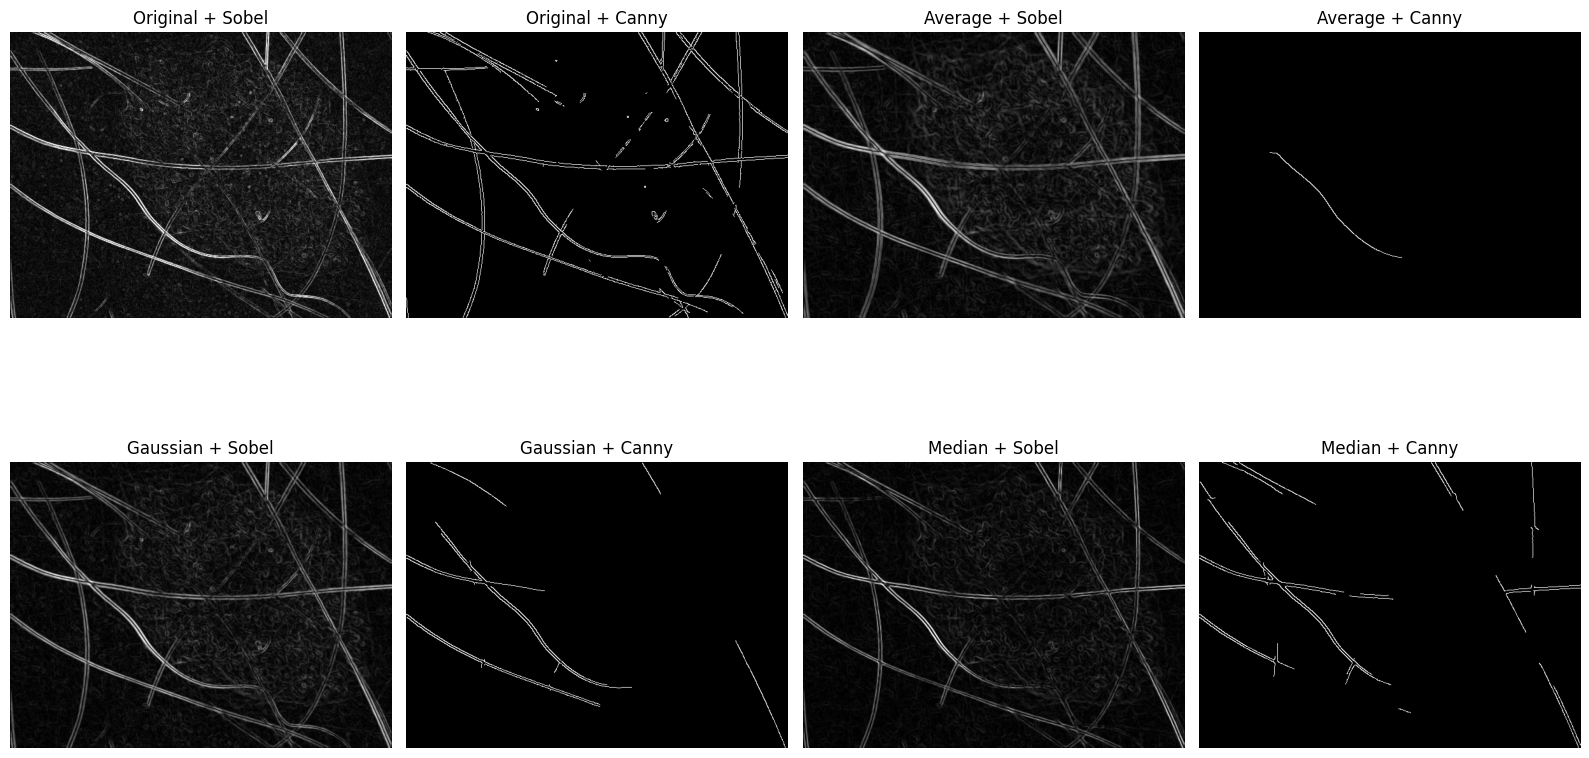

In [17]:
# Read first image
img = cv2.imread(selected_images[0])

# Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Different filters
original = gray.copy()

average = cv2.blur(gray, (5, 5))

gaussian = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)

median = cv2.medianBlur(
    gray,
    5
)


# Function for Sobel
def sobel_edges(image):

    sobel_x = cv2.Sobel(
        image,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    sobel_y = cv2.Sobel(
        image,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    magnitude = cv2.magnitude(
        np.float32(np.abs(sobel_x)),
        np.float32(np.abs(sobel_y))
    )

    magnitude = cv2.convertScaleAbs(magnitude)

    return magnitude


# Generate Sobel
sobel_original = sobel_edges(original)
sobel_average = sobel_edges(average)
sobel_gaussian = sobel_edges(gaussian)
sobel_median = sobel_edges(median)


# Generate Canny
canny_original = cv2.Canny(
    original,
    100,
    200
)

canny_average = cv2.Canny(
    average,
    100,
    200
)

canny_gaussian = cv2.Canny(
    gaussian,
    100,
    200
)

canny_median = cv2.Canny(
    median,
    100,
    200
)


# Display all results
plt.figure(figsize=(16, 10))

images = [
    sobel_original,
    canny_original,
    sobel_average,
    canny_average,
    sobel_gaussian,
    canny_gaussian,
    sobel_median,
    canny_median
]

titles = [
    "Original + Sobel",
    "Original + Canny",
    "Average + Sobel",
    "Average + Canny",
    "Gaussian + Sobel",
    "Gaussian + Canny",
    "Median + Sobel",
    "Median + Canny"
]

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i], cmap="gray")

    plt.title(titles[i])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
comparison_table = pd.DataFrame({
    "Method": [
        "Original + Sobel",
        "Original + Canny",
        "Average + Sobel",
        "Average + Canny",
        "Gaussian + Sobel",
        "Gaussian + Canny",
        "Median + Sobel",
        "Median + Canny"
    ],

    "Noise Handling": [
        "Low",
        "Low",
        "Moderate",
        "Moderate",
        "Good",
        "Good",
        "Very Good",
        "Very Good"
    ],

    "Edge Quality": [
        "Moderate",
        "Good",
        "Moderate",
        "Good",
        "Good",
        "Very Good",
        "Good",
        "Very Good"
    ],

    "Boundary Detection": [
        "Moderate",
        "Good",
        "Moderate",
        "Good",
        "Good",
        "Very Good",
        "Good",
        "Very Good"
    ],

    "Overall Performance": [
        "Moderate",
        "Good",
        "Moderate",
        "Good",
        "Good",
        "Very Good",
        "Good",
        "Very Good"
    ]
})

comparison_table

,Method,Noise Handling,Edge Quality,Boundary Detection,Overall Performance
0,Original + Sobel,Low,Moderate,Moderate,Moderate
1,Original + Canny,Low,Good,Good,Good
2,Average + Sobel,Moderate,Moderate,Moderate,Moderate
3,Average + Canny,Moderate,Good,Good,Good
4,Gaussian + Sobel,Good,Good,Good,Good
5,Gaussian + Canny,Good,Very Good,Very Good,Very Good
6,Median + Sobel,Very Good,Good,Good,Good
7,Median + Canny,Very Good,Very Good,Very Good,Very Good
